# KL Metric for Quantifying Summary Loss

In [29]:
from dotenv import load_dotenv
load_dotenv()

True

In [30]:
import os
os.environ['HF_ROOT']

'/home/jennifer/scratch/jennifer/hf'

In [31]:
import os
from pathlib import Path

hf_root = Path(os.environ['HF_ROOT'])
hf_root.mkdir(parents=True, exist_ok=True)
(hf_root / "transformers").mkdir(parents=True, exist_ok=True)
(hf_root / "datasets").mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(hf_root)
os.environ["TRANSFORMERS_CACHE"] = str(hf_root / "transformers")
os.environ["HF_DATASETS_CACHE"] = str(hf_root / "datasets")

hf_root

PosixPath('/home/jennifer/scratch/jennifer/hf')

In [32]:
os.environ["HF_HOME"]

'/home/jennifer/scratch/jennifer/hf'

In [33]:
from datasets import load_dataset

# # Login using e.g. `huggingface-cli login` to access this dataset
# ot_ds = load_dataset("open-thoughts/OpenThoughts3-1.2M")

In [34]:
# om_ds = load_dataset("microsoft/OpenMementos")
om_ds = load_dataset("microsoft/OpenMementos", "full", split="train")

In [35]:
# ot_ds

In [36]:
om_ds

Dataset({
    features: ['problem', 'response', 'domain', 'source', 'difficulty', 'sentences', 'blocks', 'block_summaries'],
    num_rows: 228557
})

In [37]:
# ot_ds['train'][0]['conversations']

In [38]:
om_ds[0]['problem']

"The problem over here introduces an new type of strings: if you split the string into equal halfs and swap the pairs, it produces the same output as sorting the string. We call that a half-sort.\nGiven a purely ASCII string, check if the string is in a half-sort.\nAn example of a half-sort string\nThe string node is a half-sort string, because if you sort by codepoints (note that the codepoints are in decimal, not binary):\nn 110\no 111\nd 100\ne 101\n\nThat gets turned into:\nd 100\ne 101\nn 110\no 111\n\nYou'll see that the node to deno conversion is exactly moving the right half to the left position.\nSpecification\n\nFor odd-length strings, splitting should make the first half longer.\nSorting a string means sorting the string based on the codepoints of the characters.\n\nReference program & test cases\nHere is the reference program I made for checking my test cases.\nnode -> True\nrum  -> True\naaa  -> True\n\ndeno -> False\nrim  -> False\n\n"

In [39]:
om_ds[0]['sentences']

["Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let's start by understanding the problem again. The half-sort is when if you split the string into two equal halves (with the first half being longer if the length is odd), then swap those two halves, the result should be the same as sorting the original string. Oh right, and splitting for odd-length means the first half is longer.",
 'Let me rephrase the example given. Take the string "node".',
 'The original characters are n, o, d, e. When sorted by their ASCII codes, they become d, e, n, o. Which is "deno".',
 'Now, splitting "node" into two halves: since it\'s 4 characters, each half is 2. The first half is \'no\' and the second is \'de\'.',
 "Swapping gives 'deno', which matches the sorted version. So that's why it's a half-sort.",
 'The task is to write a function that checks if a given string satisfies this condition.',
 "So the steps I need to do are:\n1. Check the length of the string. If i

## Correspondence of summaries and sentences

In [40]:
print(om_ds[0]['blocks'])
print(len(om_ds[0]['blocks']))

[[0, 4], [5, 17], [18, 29], [30, 34], [35, 42], [43, 54], [55, 59]]
7


In [41]:
print(om_ds[0]['block_summaries'])
print(len(om_ds[0]['block_summaries']))

['Clarifies definition of half-sort: split string into two halves (first half longer if length odd), swap halves; if swapped string equals the sorted string (by ASCII/codepoints), input is considered half-sort. Verifies example "node": length 4 -> split "no" | "de", swap -> "deno", which matches sorted("node") = "deno".', "Plans function to check property. Handles small lengths: length 0 and 1 considered half-sort (length 1: split as first half 1 char, second empty; swap unchanged; sorted equals original). For general length n: define left_len = (len(s)+1)//2, right_len = len(s) - left_len; left = s[:left_len], right = s[left_len:], swapped = right + left; sorted_s = ''.join(sorted(s)); return swapped == sorted_s. Sorting uses default order (ASCII/codepoints).", 'Defines split rule: left_len = (n+1)//2; left = s[:left_len]; right = s[left_len:]; half-sort test is right+left == \'\'.join(sorted(s)). Applies rule to examples: node -> left "no", right "de", swapped "deno" equals sorted "d

In [42]:
len(om_ds[0]['sentences'])

60

In [43]:
data = om_ds[0]

In [44]:
data['sentences'][data['blocks'][0][0] : data['blocks'][0][1]]

["Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let's start by understanding the problem again. The half-sort is when if you split the string into two equal halves (with the first half being longer if the length is odd), then swap those two halves, the result should be the same as sorting the original string. Oh right, and splitting for odd-length means the first half is longer.",
 'Let me rephrase the example given. Take the string "node".',
 'The original characters are n, o, d, e. When sorted by their ASCII codes, they become d, e, n, o. Which is "deno".',
 'Now, splitting "node" into two halves: since it\'s 4 characters, each half is 2. The first half is \'no\' and the second is \'de\'.']

In [45]:
len(data['block_summaries'][0])

319

## Evaluating summaries

## Loading model

In [46]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    trust_remote_code=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def ask_qwen(prompt, max_new_tokens=256, temperature=0.7):
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(text, return_tensors="pt").to(device)

    generation_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "pad_token_id": tokenizer.eos_token_id,
    }
    if temperature > 0:
        generation_kwargs["temperature"] = temperature

    with torch.no_grad():
        output = model.generate(
            **inputs,
            **generation_kwargs,
        )

    generated_tokens = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True)

print(f"Loaded {MODEL_ID} on {device} with dtype={dtype}")

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 3294.79it/s]


Loaded Qwen/Qwen3-1.7B on cuda with dtype=torch.bfloat16


In [47]:
import torch

def token_logits(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return tokens, logits[0]  # shape: [seq_len, vocab_size]

tokens, logits = token_logits("Hello, World")
print(tokens)
print(logits.shape)


['Hello', ',', 'ĠWorld']
torch.Size([3, 151936])


The Ġ is just a marker for “there was a space before this token.”

In [48]:
logits.shape

torch.Size([3, 151936])

In [49]:
def next_token_scores(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits[0]

    input_ids = inputs["input_ids"][0]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    next_logits = logits[:-1]          # predicts token 1..n-1
    next_token_ids = input_ids[1:]     # actual tokens 1..n-1
    actual_token_logits = next_logits.gather(
        1, next_token_ids.unsqueeze(1)
    ).squeeze(1)

    return tokens[1:], actual_token_logits

tokens, scores = next_token_scores("Hello world")
for tok, score in zip(tokens, scores.tolist()):
    print(tok, score)


Ġworld 1.640625


In [50]:
import pandas as pd
import torch.nn.functional as F

row = om_ds[0]
block_start, block_end = row["blocks"][0]

summary_text = row["block_summaries"][0]
relevant_text = " ".join(row["sentences"][block_start:block_end + 1])

def token_score_table(text, label):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits[0]

    input_ids = inputs["input_ids"][0]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    next_logits = logits[:-1]
    next_token_ids = input_ids[1:]
    next_tokens = tokenizer.convert_ids_to_tokens(next_token_ids)

    actual_token_logits = next_logits.gather(1, next_token_ids.unsqueeze(1)).squeeze(1)
    log_probs = F.log_softmax(next_logits, dim=-1)
    actual_token_logprobs = log_probs.gather(1, next_token_ids.unsqueeze(1)).squeeze(1)

    return pd.DataFrame({
        "text_label": label,
        "context_token": tokens[:-1],
        "predicted_token": next_tokens,
        "actual_token_logit": actual_token_logits.detach().cpu().tolist(),
        "actual_token_logprob": actual_token_logprobs.detach().cpu().tolist(),
    })

summary_scores = token_score_table(summary_text, "summary_block_0")
relevant_scores = token_score_table(relevant_text, "relevant_sentences_0_4")

comparison = pd.DataFrame([
    {
        "text_label": "summary_block_0",
        "num_chars": len(summary_text),
        "num_tokens": len(summary_scores),
        "mean_actual_token_logit": summary_scores["actual_token_logit"].mean(),
        "mean_actual_token_logprob": summary_scores["actual_token_logprob"].mean(),
    },
    {
        "text_label": "relevant_sentences_0_4",
        "num_chars": len(relevant_text),
        "num_tokens": len(relevant_scores),
        "mean_actual_token_logit": relevant_scores["actual_token_logit"].mean(),
        "mean_actual_token_logprob": relevant_scores["actual_token_logprob"].mean(),
    },
])

print("First summary block:\n", summary_text, "\n", sep="")
print("Relevant sentences:\n", relevant_text, "\n", sep="")
comparison

First summary block:
Clarifies definition of half-sort: split string into two halves (first half longer if length odd), swap halves; if swapped string equals the sorted string (by ASCII/codepoints), input is considered half-sort. Verifies example "node": length 4 -> split "no" | "de", swap -> "deno", which matches sorted("node") = "deno".

Relevant sentences:
Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let's start by understanding the problem again. The half-sort is when if you split the string into two equal halves (with the first half being longer if the length is odd), then swap those two halves, the result should be the same as sorting the original string. Oh right, and splitting for odd-length means the first half is longer. Let me rephrase the example given. Take the string "node". The original characters are n, o, d, e. When sorted by their ASCII codes, they become d, e, n, o. Which is "deno". Now, splitting "node" into two halves: since

,text_label,num_chars,num_tokens,mean_actual_token_logit,mean_actual_token_logprob
0,summary_block_0,319,76,23.602796,-3.763783
1,relevant_sentences_0_4,809,199,29.817211,-1.737487


In [51]:
import torch.nn.functional as F

def get_final_logits(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        return model(**inputs).logits[0, -1]  # [vocab_size]

sentences_logits = get_final_logits(relevant_text)
summary_logits   = get_final_logits(summary_text)

sentences_probs     = F.softmax(sentences_logits,     dim=-1)
summary_probs       = F.softmax(summary_logits,       dim=-1)
sentences_log_probs = F.log_softmax(sentences_logits, dim=-1)
summary_log_probs   = F.log_softmax(summary_logits,   dim=-1)

kl_summ_sent = F.kl_div(sentences_log_probs, summary_probs,   reduction="sum")
kl_sent_summ = F.kl_div(summary_log_probs,   sentences_probs, reduction="sum")

print(f"KL(future|summary   || future|sentences) = {kl_summ_sent.item():.4f}")
print(f"KL(future|sentences || future|summary)   = {kl_sent_summ.item():.4f}")


KL(future|summary   || future|sentences) = 3.8125
KL(future|sentences || future|summary)   = 1.8984


In [52]:
block1_start, block1_end = row["blocks"][1]
next_block_text = " ".join(row["sentences"][block1_start:block1_end + 1])

def continuation_logprobs(prefix_text, continuation_text, max_total_tokens=1024):
    """Per-token log-probs of continuation tokens conditioned on prefix.

    Truncates the prefix (from the left) if prefix+continuation would exceed
    max_total_tokens, so the continuation is always scored in full.
    """
    cont_ids   = tokenizer(continuation_text, return_tensors="pt")["input_ids"][0]
    prefix_ids = tokenizer(prefix_text,       return_tensors="pt")["input_ids"][0]

    max_prefix = max_total_tokens - len(cont_ids)
    if max_prefix <= 0:
        # continuation alone is too long — truncate it too, keeping the start
        cont_ids   = cont_ids[:max_total_tokens - 1]
        max_prefix = 1
    if len(prefix_ids) > max_prefix:
        prefix_ids = prefix_ids[-max_prefix:]   # keep most recent context

    full_ids   = torch.cat([prefix_ids, cont_ids]).unsqueeze(0).to(device)
    prefix_len = len(prefix_ids)

    with torch.no_grad():
        logits = model(input_ids=full_ids).logits[0]

    cont_logits    = logits[prefix_len - 1 : -1]
    log_probs      = F.log_softmax(cont_logits, dim=-1)
    token_logprobs = log_probs.gather(1, cont_ids.to(device).unsqueeze(1)).squeeze(1)
    cont_tokens    = tokenizer.convert_ids_to_tokens(cont_ids)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return cont_tokens, token_logprobs

tokens_sent, lp_sent = continuation_logprobs(relevant_text, next_block_text)
tokens_summ, lp_summ = continuation_logprobs(summary_text,  next_block_text)

print(f"blocks[1] | sentences prefix:  mean log-prob = {lp_sent.mean().item():.4f}  perplexity = {torch.exp(-lp_sent.mean()).item():.2f}")
print(f"blocks[1] | summary  prefix:   mean log-prob = {lp_summ.mean().item():.4f}  perplexity = {torch.exp(-lp_summ.mean()).item():.2f}")

blocks[1] | sentences prefix:  mean log-prob = -1.4375  perplexity = 4.22
blocks[1] | summary  prefix:   mean log-prob = -1.4375  perplexity = 4.22


In [53]:
results = []

for i in range(len(row["blocks"]) - 1):
    s, e   = row["blocks"][i]
    s1, e1 = row["blocks"][i + 1]

    prefix_sentences = " ".join(row["sentences"][s  : e  + 1])
    prefix_summary   = row["block_summaries"][i]
    next_block_text  = " ".join(row["sentences"][s1 : e1 + 1])

    _, lp_sent = continuation_logprobs(prefix_sentences, next_block_text)
    _, lp_summ = continuation_logprobs(prefix_summary,   next_block_text)

    results.append({
        "block": i,
        "next_block_text": next_block_text,
        "n_tokens_next": len(lp_sent),
        "mean_logprob_sentences": lp_sent.mean().item(),
        "mean_logprob_summary":   lp_summ.mean().item(),
        "perplexity_sentences":   torch.exp(-lp_sent.mean()).item(),
        "perplexity_summary":     torch.exp(-lp_summ.mean()).item(),
    })

df = pd.DataFrame(results)
df["perplexity_delta"] = df["perplexity_summary"] - df["perplexity_sentences"]
df

,block,next_block_text,n_tokens_next,mean_logprob_sentences,mean_logprob_summary,perplexity_sentences,perplexity_summary,perplexity_delta
0,0,The task is to write a function that checks if...,737,-1.437500,-1.437500,4.21875,4.21875,0.00000
1,1,"Wait, yes. So this is straightforward. But I n...",654,-1.750000,-1.781250,5.75000,5.93750,0.18750
2,2,"Now, to code this. So first, in Python, the st...",342,-1.539062,-1.656250,4.65625,5.25000,0.59375
3,3,Now the edge cases:\nTest string of length 1:\...,385,-1.671875,-1.851562,5.31250,6.37500,1.06250
4,4,So the code seems correct. Wait what about 'aa...,604,-1.562500,-1.718750,4.78125,5.56250,0.78125
5,5,"Therefore, the code should work. Now I need to...",357,-1.750000,-1.820312,5.75000,6.18750,0.43750


## Running context: cumulative sentences vs cumulative summaries

In [54]:
running_results = []

for i in range(len(row["blocks"]) - 1):
    s1, e1 = row["blocks"][i + 1]
    next_block_text = " ".join(row["sentences"][s1 : e1 + 1])

    # cumulative sentences: all sentences from blocks 0..i
    s0, _ = row["blocks"][0]
    _, ei  = row["blocks"][i]
    running_sentences = " ".join(row["sentences"][s0 : ei + 1])

    # cumulative summaries: all summaries from blocks 0..i
    running_summary = " ".join(row["block_summaries"][: i + 1])

    _, lp_sent = continuation_logprobs(running_sentences, next_block_text)
    _, lp_summ = continuation_logprobs(running_summary,   next_block_text)

    running_results.append({
        "block": i,
        "next_block_text": next_block_text,
        "n_tokens_next": len(lp_sent),
        "mean_logprob_sentences": lp_sent.mean().item(),
        "mean_logprob_summary":   lp_summ.mean().item(),
        "perplexity_sentences":   torch.exp(-lp_sent.mean()).item(),
        "perplexity_summary":     torch.exp(-lp_summ.mean()).item(),
    })

df_running = pd.DataFrame(running_results)
df_running["perplexity_delta"] = df_running["perplexity_summary"] - df_running["perplexity_sentences"]
df_running

,block,next_block_text,n_tokens_next,mean_logprob_sentences,mean_logprob_summary,perplexity_sentences,perplexity_summary,perplexity_delta
0,0,The task is to write a function that checks if...,737,-1.437500,-1.437500,4.21875,4.21875,0.00000
1,1,"Wait, yes. So this is straightforward. But I n...",654,-1.750000,-1.789062,5.75000,5.96875,0.21875
2,2,"Now, to code this. So first, in Python, the st...",342,-1.492188,-1.640625,4.43750,5.15625,0.71875
3,3,Now the edge cases:\nTest string of length 1:\...,385,-1.570312,-1.742188,4.81250,5.71875,0.90625
4,4,So the code seems correct. Wait what about 'aa...,604,-1.554688,-1.656250,4.71875,5.25000,0.53125
5,5,"Therefore, the code should work. Now I need to...",357,-1.718750,-1.585938,5.56250,4.87500,-0.68750


In [55]:
def generate_continuation(prefix_text, max_new_tokens=150):
    inputs = tokenizer(prefix_text, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy — deterministic
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


SEP = "-" * 80

for i in range(len(row["blocks"]) - 1):
    s,  e  = row["blocks"][i]
    s1, e1 = row["blocks"][i + 1]

    prefix_sentences = " ".join(row["sentences"][s  : e  + 1])
    prefix_summary   = row["block_summaries"][i]
    actual_next      = " ".join(row["sentences"][s1 : e1 + 1])

    gen_from_sentences = generate_continuation(prefix_sentences)
    gen_from_summary   = generate_continuation(prefix_summary)

    print(f"\n{'=' * 80}")
    print(f"BLOCK {i} → predicting block {i+1}")
    print(f"{SEP}\nACTUAL next block:\n{actual_next}")
    print(f"{SEP}\nGENERATED from sentences:\n{gen_from_sentences}")
    print(f"{SEP}\nGENERATED from summary:\n{gen_from_summary}")


BLOCK 0 → predicting block 1
--------------------------------------------------------------------------------
ACTUAL next block:
The task is to write a function that checks if a given string satisfies this condition. So the steps I need to do are:
1. Check the length of the string. If it's 0 or 1, maybe it's trivially half-sort? Wait, if length is 1, then splitting into halves would just have the first half as the entire string and the second as empty? Or maybe according to the specs, for odd length, first half is longer. So length 1 would be first half (1 char), second half none?
So swapping would mean moving the second (empty) to front and first part to end, but that would be the same?
Hmm, but let's see. Maybe for length 1, the split is first half (1), second half (0). Swapping them gives the original string. Then the sorted version must also be the original. So only if the string is already sorted, which a single character is. So for length 1, it would return True. 2. For the gene

## Multi-row perplexity comparison

In [56]:
def row_continuation_results(row_data):
    """Per-block continuation log-probs for one dataset row."""
    results = []
    for i in range(len(row_data["blocks"]) - 1):
        s,  e  = row_data["blocks"][i]
        s1, e1 = row_data["blocks"][i + 1]

        prefix_sentences = " ".join(row_data["sentences"][s  : e  + 1])
        prefix_summary   = row_data["block_summaries"][i]
        next_block_text  = " ".join(row_data["sentences"][s1 : e1 + 1])

        _, lp_sent = continuation_logprobs(prefix_sentences, next_block_text)
        _, lp_summ = continuation_logprobs(prefix_summary,   next_block_text)

        results.append({
            "mean_logprob_sentences": lp_sent.mean().item(),
            "mean_logprob_summary":   lp_summ.mean().item(),
            "perplexity_sentences":   torch.exp(-lp_sent.mean()).item(),
            "perplexity_summary":     torch.exp(-lp_summ.mean()).item(),
        })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results


N_ROWS = 10  # increase if memory allows

all_results = []
for row_idx in range(N_ROWS):
    for block_result in row_continuation_results(om_ds[row_idx]):
        all_results.append({"row": row_idx, **block_result})
    print(f"done row {row_idx}")

df_all = pd.DataFrame(all_results)
df_all["perplexity_delta"] = df_all["perplexity_summary"] - df_all["perplexity_sentences"]
df_all["logprob_delta"]    = df_all["mean_logprob_summary"] - df_all["mean_logprob_sentences"]
df_all

done row 0
done row 1
done row 2
done row 3
done row 4
done row 5
done row 6
done row 7
done row 8
done row 9


,row,mean_logprob_sentences,mean_logprob_summary,perplexity_sentences,perplexity_summary,perplexity_delta,logprob_delta
0,0,-1.437500,-1.437500,4.21875,4.21875,0.00000,0.000000
1,0,-1.750000,-1.781250,5.75000,5.93750,0.18750,-0.031250
2,0,-1.539062,-1.656250,4.65625,5.25000,0.59375,-0.117188
3,0,-1.671875,-1.851562,5.31250,6.37500,1.06250,-0.179688
4,0,-1.562500,-1.718750,4.78125,5.56250,0.78125,-0.156250
...,...,...,...,...,...,...,...
65,9,-2.140625,-2.156250,8.50000,8.62500,0.12500,-0.015625
66,9,-1.984375,-1.968750,7.28125,7.15625,-0.12500,0.015625
67,9,-2.187500,-2.187500,8.93750,8.93750,0.00000,0.000000
68,9,-1.968750,-1.937500,7.15625,6.93750,-0.21875,0.031250


In [61]:
df_all

,row,mean_logprob_sentences,mean_logprob_summary,perplexity_sentences,perplexity_summary,perplexity_delta,logprob_delta
0,0,-1.437500,-1.437500,4.21875,4.21875,0.00000,0.000000
1,0,-1.750000,-1.781250,5.75000,5.93750,0.18750,-0.031250
2,0,-1.539062,-1.656250,4.65625,5.25000,0.59375,-0.117188
3,0,-1.671875,-1.851562,5.31250,6.37500,1.06250,-0.179688
4,0,-1.562500,-1.718750,4.78125,5.56250,0.78125,-0.156250
...,...,...,...,...,...,...,...
65,9,-2.140625,-2.156250,8.50000,8.62500,0.12500,-0.015625
66,9,-1.984375,-1.968750,7.28125,7.15625,-0.12500,0.015625
67,9,-2.187500,-2.187500,8.93750,8.93750,0.00000,0.000000
68,9,-1.968750,-1.937500,7.15625,6.93750,-0.21875,0.031250


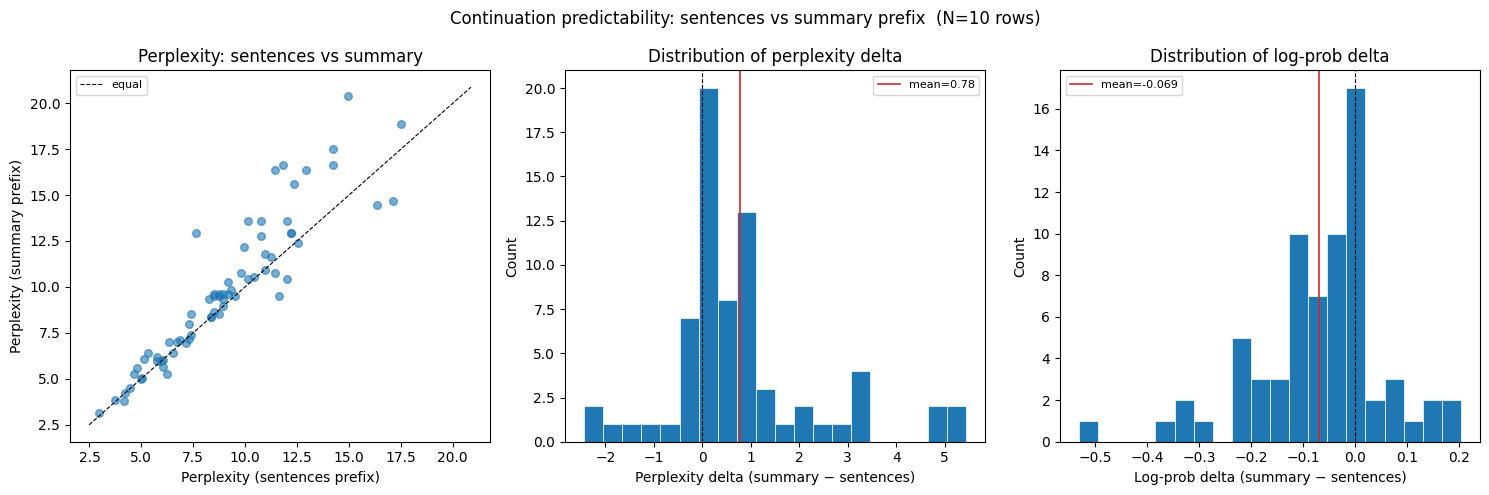

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- 1. Scatter: perplexity sentences vs summary, one point per block ---
ax = axes[0]
ax.scatter(df_all["perplexity_sentences"], df_all["perplexity_summary"], alpha=0.6, s=30)
lims = [
    min(df_all["perplexity_sentences"].min(), df_all["perplexity_summary"].min()) - 0.5,
    max(df_all["perplexity_sentences"].max(), df_all["perplexity_summary"].max()) + 0.5,
]
ax.plot(lims, lims, "k--", linewidth=0.8, label="equal")
ax.set_xlabel("Perplexity (sentences prefix)")
ax.set_ylabel("Perplexity (summary prefix)")
ax.set_title("Perplexity: sentences vs summary")
ax.legend(fontsize=8)

# --- 2. Histogram of perplexity_delta (summary − sentences) ---
ax = axes[1]
ax.hist(df_all["perplexity_delta"], bins=20, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
ax.axvline(df_all["perplexity_delta"].mean(), color="tab:red", linestyle="-", linewidth=1.2, label=f"mean={df_all['perplexity_delta'].mean():.2f}")
ax.set_xlabel("Perplexity delta (summary − sentences)")
ax.set_ylabel("Count")
ax.set_title("Distribution of perplexity delta")
ax.legend(fontsize=8)

# --- 3. Histogram of log-prob delta (summary − sentences) ---
ax = axes[2]
ax.hist(df_all["logprob_delta"], bins=20, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
ax.axvline(df_all["logprob_delta"].mean(), color="tab:red", linestyle="-", linewidth=1.2, label=f"mean={df_all['logprob_delta'].mean():.3f}")
ax.set_xlabel("Log-prob delta (summary − sentences)")
ax.set_ylabel("Count")
ax.set_title("Distribution of log-prob delta")
ax.legend(fontsize=8)

fig.suptitle(f"Continuation predictability: sentences vs summary prefix  (N={N_ROWS} rows)", fontsize=12)
plt.tight_layout()
plt.show()

In [59]:
summary_text

'Clarifies definition of half-sort: split string into two halves (first half longer if length odd), swap halves; if swapped string equals the sorted string (by ASCII/codepoints), input is considered half-sort. Verifies example "node": length 4 -> split "no" | "de", swap -> "deno", which matches sorted("node") = "deno".'

In [60]:
relevant_text

'Okay, so I need to figure out how to determine if a given string is a half-sort. Hmm, let\'s start by understanding the problem again. The half-sort is when if you split the string into two equal halves (with the first half being longer if the length is odd), then swap those two halves, the result should be the same as sorting the original string. Oh right, and splitting for odd-length means the first half is longer. Let me rephrase the example given. Take the string "node". The original characters are n, o, d, e. When sorted by their ASCII codes, they become d, e, n, o. Which is "deno". Now, splitting "node" into two halves: since it\'s 4 characters, each half is 2. The first half is \'no\' and the second is \'de\'. Swapping gives \'deno\', which matches the sorted version. So that\'s why it\'s a half-sort.'